# Sign Language Classification using CNN
### 6CS012 - Artificial Intelligence and Machine Learning

**Assignment:** Part II - Vision Tasks  
**Task:** Image Classification using Convolutional Neural Networks  
**Dataset:** Sign Language Detection (38 Classes)  


## 0. Setup and Imports
Run this first to install and import everything needed for the notebook.

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

gpu_list = tf.config.list_physical_devices('GPU')
if gpu_list:
    tf.config.experimental.set_memory_growth(gpu_list[0], True)
    print(f"GPU ready: {gpu_list[0].name}")
else:
    print("No GPU found. Running on CPU.")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


C:\Users\samye\anaconda3\envs\tf-gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow version: 2.10.0
NumPy version: 1.26.4
GPU ready: /physical_device:GPU:0
TF version: 2.10.0


## 1. Dataset Path Configuration

Update `DATA_ROOT` below to point to where the Sign Language dataset is saved.  
It should contain a `Train/` and `Test/` folder, each with sub-folders named `0` through `37`.

In [8]:
DATA_ROOT  = r"C:\Users\samye\AI workshops\Assessment\Sign Language Detection"

TRAIN_PATH = os.path.join(DATA_ROOT, "Train")
TEST_PATH  = os.path.join(DATA_ROOT, "Test")

IMG_H         = 64
IMG_W         = 64
BATCH         = 32
N_CLASSES     = 38
MAX_EPOCHS_A  = 20
MAX_EPOCHS_B  = 30
MAX_EPOCHS_TL = 20

print("Train directory:", TRAIN_PATH)
print("Test  directory:", TEST_PATH)
print(f"Image size      : {IMG_H}x{IMG_W}")
print(f"Batch size      : {BATCH}")
print(f"Number of classes: {N_CLASSES}")


Train directory: C:\Users\samye\AI workshops\Assessment\Sign Language Detection\Train
Test  directory: C:\Users\samye\AI workshops\Assessment\Sign Language Detection\Test
Image size      : 64x64
Batch size      : 32
Number of classes: 38


## 2. Part A - Data Understanding, Analysis, Visualisation and Cleaning

### 2.1 Dataset Overview

### Counting classes and images

We walk through the `Train/` folder to count how many images exist per class, and do the same for `Test/`. This gives a quick sanity check on dataset size and helps spot any class imbalance before we start training.

In [9]:
labels = sorted(os.listdir(TRAIN_PATH), key=lambda x: int(x))

train_counts = {}
for lbl in labels:
    lbl_dir = os.path.join(TRAIN_PATH, lbl)
    if os.path.isdir(lbl_dir):
        train_counts[lbl] = len(os.listdir(lbl_dir))

n_train_total = sum(train_counts.values())

test_counts = {}
for lbl in os.listdir(TEST_PATH):
    lbl_dir = os.path.join(TEST_PATH, lbl)
    if os.path.isdir(lbl_dir):
        test_counts[lbl] = len(os.listdir(lbl_dir))
n_test_total = sum(test_counts.values())

print(f"Number of classes : {len(labels)}")
print(f"Total train images: {n_train_total}")
print(f"Total test  images: {n_test_total}")
print(f"Total images      : {n_train_total + n_test_total}")
print("\nPer-class image count (Train):")
for lbl, cnt in train_counts.items():
    print(f"  Class {lbl:>3}: {cnt} images")


Number of classes : 38
Total train images: 10792
Total test  images: 0
Total images      : 10792

Per-class image count (Train):
  Class   0: 286 images
  Class   1: 287 images
  Class   2: 291 images
  Class   3: 279 images
  Class   4: 239 images
  Class   5: 287 images
  Class   6: 284 images
  Class   7: 282 images
  Class   8: 290 images
  Class   9: 285 images
  Class  10: 291 images
  Class  11: 284 images
  Class  12: 277 images
  Class  13: 279 images
  Class  14: 270 images
  Class  15: 287 images
  Class  16: 291 images
  Class  17: 286 images
  Class  18: 287 images
  Class  19: 288 images
  Class  20: 286 images
  Class  21: 286 images
  Class  22: 293 images
  Class  23: 285 images
  Class  24: 290 images
  Class  25: 287 images
  Class  26: 285 images
  Class  27: 286 images
  Class  28: 284 images
  Class  29: 285 images
  Class  30: 285 images
  Class  31: 288 images
  Class  32: 281 images
  Class  33: 288 images
  Class  34: 283 images
  Class  35: 279 images
  Class

### Class distribution bar chart

Plotting image counts per class to visually confirm balance. If one class had way more images than others it could skew training, so we check this before going any further.

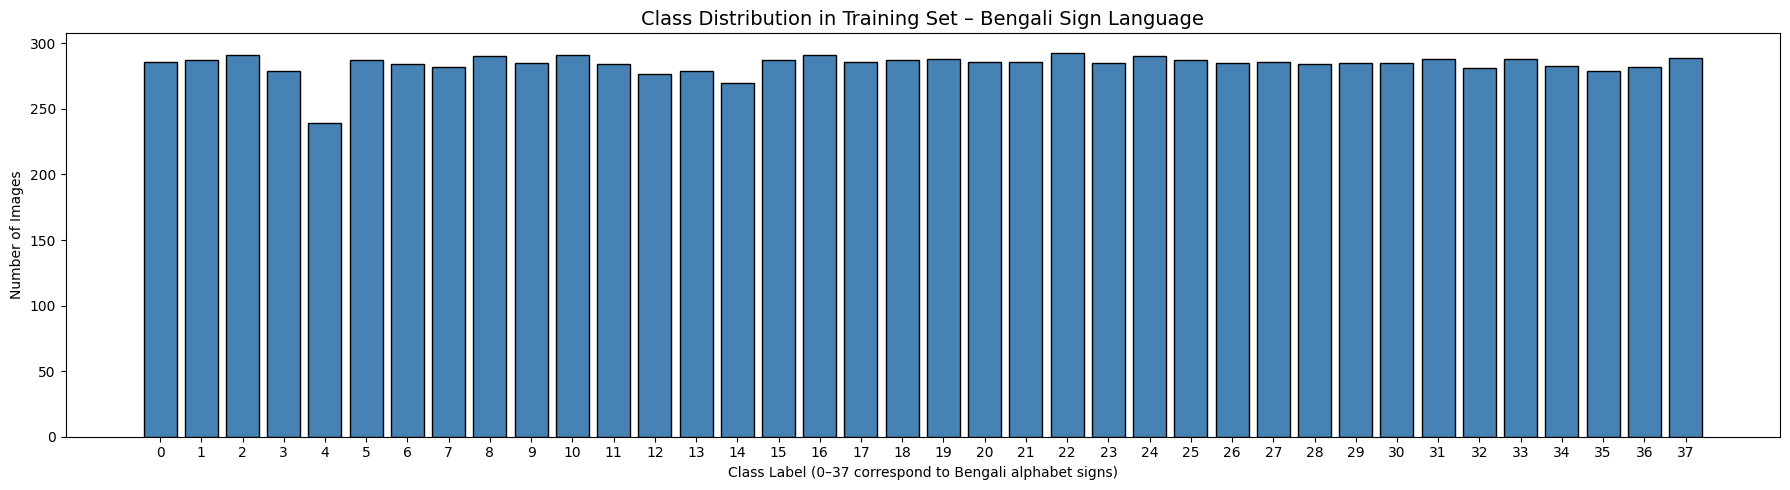

Observation: The dataset appears roughly balanced across all 38 classes.


In [ ]:
plt.figure(figsize=(18, 5))
plt.bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set - Bengali Sign Language', fontsize=14)
plt.xlabel('Class Label (0-37 correspond to Bengali alphabet signs)')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150)
plt.show()
print("Observation: The dataset looks fairly balanced across all 38 classes.")


Min images : 239 (Class 4)
Max images : 293 (Class 22)
Imbalance ratio : 1.23

### Sample images from the dataset

Showing one image per class for the first 24 classes so we can see what the raw data actually looks like before any preprocessing is applied.

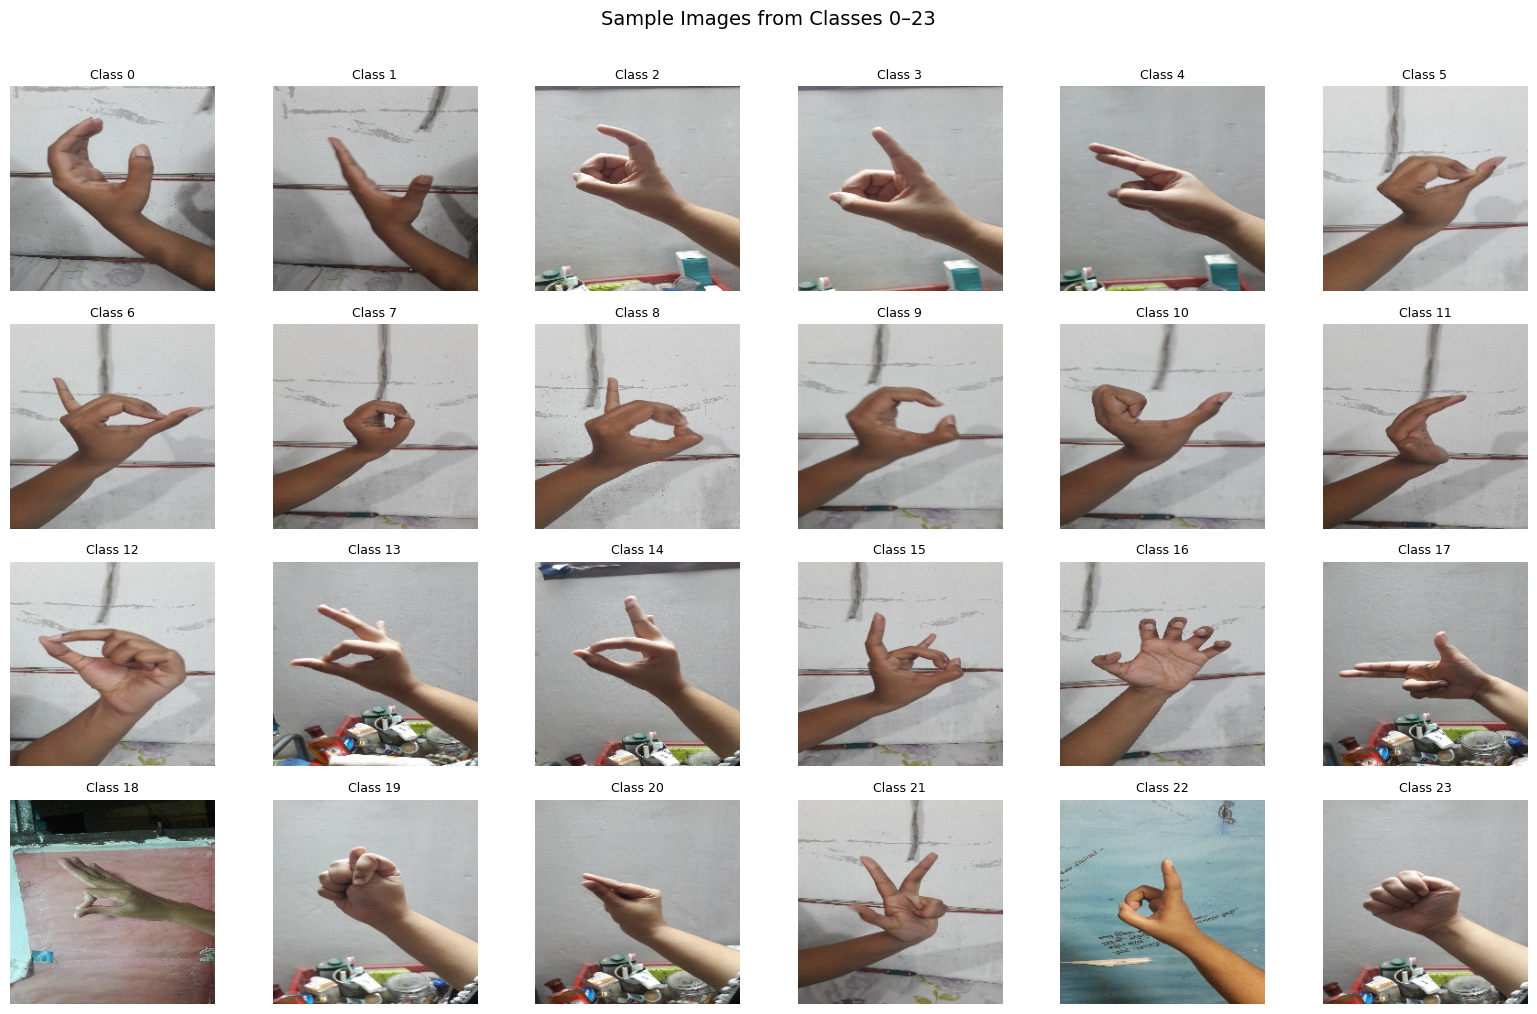

In [11]:
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
axes = axes.flatten()

preview_classes = list(train_counts.keys())[:24]
for idx, lbl in enumerate(preview_classes):
    lbl_dir  = os.path.join(TRAIN_PATH, lbl)
    img_name = os.listdir(lbl_dir)[0]
    img      = mpimg.imread(os.path.join(lbl_dir, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class {lbl}', fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Sample Images from Classes 0-23', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig2_sample_images.png', dpi=150)
plt.show()


### 2.2 Data Preprocessing and Augmentation

Steps applied before training:
- **Resize** all images to 64x64 so the input shape is consistent.
- **Normalise** pixel values to [0, 1] by dividing by 255.
- **Augmentation** applied only to the training set (rotation, zoom, shift) to help the model generalise.
- Validation set only gets rescaling, no augmentation, so evaluation results are reliable.
- `horizontal_flip=False` because Bengali sign handshapes are not symmetric, flipping changes the meaning.

### Setting up data generators

We use Keras `ImageDataGenerator` to handle loading, resizing, normalising and augmenting images on the fly. The training generator applies random rotation, shift and zoom to artificially expand the training set. The validation generator only rescales, no augmentation, so validation accuracy reflects real performance. An 80/20 split is applied via `validation_split=0.2`.

In [32]:
aug_gen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    validation_split=0.2
)

plain_gen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = aug_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    seed=RANDOM_SEED
)

val_gen = aug_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    seed=RANDOM_SEED
)

print(f"\nTraining samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")


Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.

Training samples   : 8648
Validation samples : 2144


### Visualising augmented samples

Taking one image from Class 0 and generating 9 augmented versions of it. This makes it easy to see whether the augmentation parameters look reasonable before committing to training.

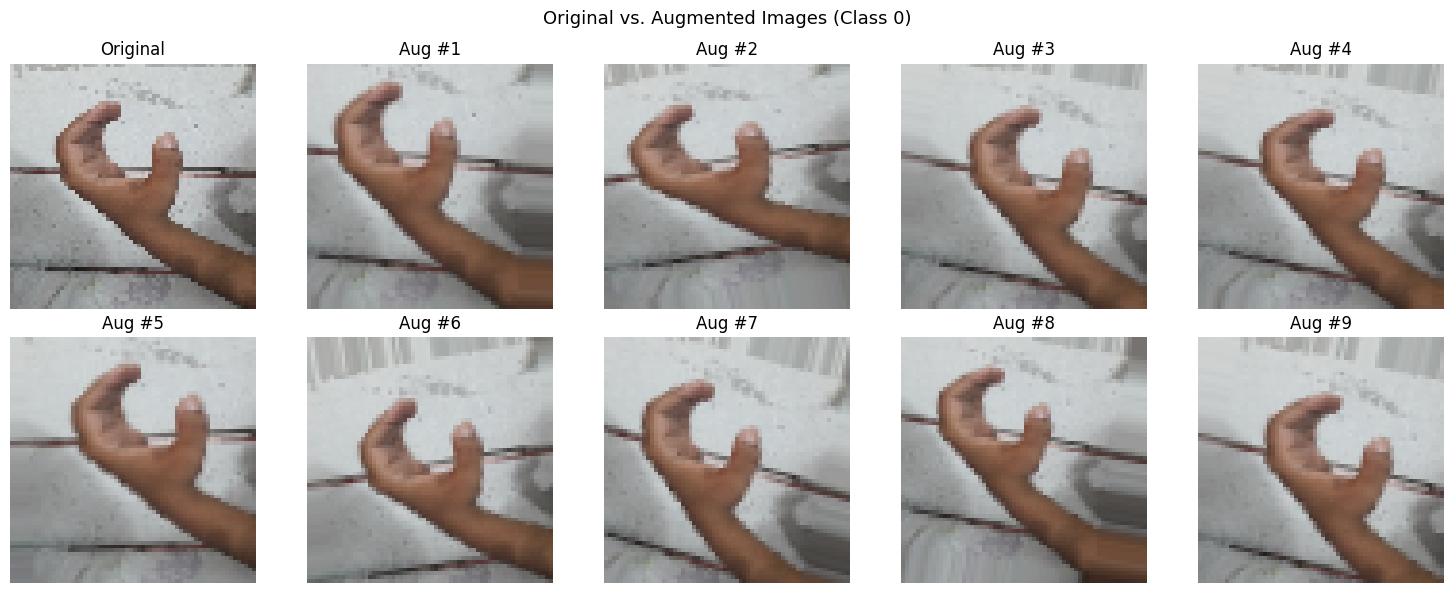

In [13]:
vis_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

ref_class = labels[0]
ref_dir   = os.path.join(TRAIN_PATH, ref_class)
ref_file  = os.path.join(ref_dir, os.listdir(ref_dir)[0])
ref_img   = tf.keras.preprocessing.image.load_img(ref_file, target_size=(IMG_H, IMG_W))
ref_arr   = tf.keras.preprocessing.image.img_to_array(ref_img)
ref_arr   = ref_arr.reshape((1,) + ref_arr.shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
axes[0].imshow(ref_img)
axes[0].set_title('Original')
axes[0].axis('off')

aug_iter = vis_datagen.flow(ref_arr, batch_size=1)
for i in range(1, 10):
    batch = next(aug_iter)
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')

plt.suptitle(f'Original vs Augmented Images (Class {ref_class})', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_augmentation.png', dpi=150)
plt.show()


### Cleaning corrupt or non-image files

Scanning both `Train/` and `Test/` for any files that are not valid images. Corrupt or misnamed files can cause the data generator to crash mid-training, so we remove them upfront.

In [14]:
from PIL import Image

def remove_bad_images(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for fname in files:
            fpath = os.path.join(root, fname)
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"Removing non-image: {fpath}")
                os.remove(fpath)
                removed += 1
                continue
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception as err:
                print(f"Removing corrupt: {fpath} ({err})")
                os.remove(fpath)
                removed += 1
    print(f"Done. Removed {removed} files.")

print("Cleaning Train folder")
remove_bad_images(TRAIN_PATH)

print("\nCleaning Test folder")
remove_bad_images(TEST_PATH)


Cleaning Train folder

Done! Removed 0 files.

Cleaning Test folder

Done! Removed 0 files.


## 3. Part A - Section 1: Baseline CNN Model

A simple starting point to measure performance before adding complexity.

Architecture:
- 3 convolutional blocks, each followed by MaxPooling
- 3 fully connected Dense layers
- Output layer with Softmax for 38 classes

### Building the baseline CNN

A straightforward 3-block CNN with no BatchNorm or Dropout. This acts as our performance baseline so we have a reference point when comparing against deeper or more regularised models later.

In [15]:
def make_baseline_cnn(input_shape=(IMG_H, IMG_W, 3), n_classes=N_CLASSES):
    net = models.Sequential(name="Baseline_CNN")

    net.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                          input_shape=input_shape, name='Conv1'))
    net.add(layers.MaxPooling2D((2, 2), name='Pool1'))

    net.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='Conv2'))
    net.add(layers.MaxPooling2D((2, 2), name='Pool2'))

    net.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='Conv3'))
    net.add(layers.MaxPooling2D((2, 2), name='Pool3'))

    net.add(layers.Flatten(name='Flatten'))

    net.add(layers.Dense(512, activation='relu', name='FC1'))
    net.add(layers.Dense(256, activation='relu', name='FC2'))
    net.add(layers.Dense(128, activation='relu', name='FC3'))

    net.add(layers.Dense(n_classes, activation='softmax', name='Output'))

    return net

model_baseline = make_baseline_cnn()
model_baseline.summary()


Model: "Baseline_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1 (Conv2D)              (None, 64, 64, 32)        896       
                                                                 
 Pool1 (MaxPooling2D)        (None, 32, 32, 32)        0         
                                                                 
 Conv2 (Conv2D)              (None, 32, 32, 64)        18496     
                                                                 
 Pool2 (MaxPooling2D)        (None, 16, 16, 64)        0         
                                                                 
 Conv3 (Conv2D)              (None, 16, 16, 128)       73856     
                                                                 
 Pool3 (MaxPooling2D)        (None, 8, 8, 128)         0         
                                                                 
 Flatten (Flatten)           (None, 8192)             

### Compiling the baseline model and setting up callbacks

Using Adam as the optimiser and categorical crossentropy as the loss function. EarlyStopping will halt training if validation accuracy stops improving for 5 epochs and restore the best weights seen during training. ReduceLROnPlateau halves the learning rate if validation loss plateaus for 3 epochs.

In [16]:
model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_baseline = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Baseline model compiled.")


Baseline model compiled successfully.


### Training the baseline CNN

Running the training loop. We time it so we can include training duration in the final comparison table.

In [33]:
print("Training Baseline CNN...")
t0_base = time.time()

hist_baseline = model_baseline.fit(
    train_gen,
    epochs=MAX_EPOCHS_A,
    validation_data=val_gen,
    callbacks=cb_baseline,
    verbose=1
)

time_baseline = time.time() - t0_base
print(f"\nBaseline training time: {time_baseline:.2f}s ({time_baseline/60:.2f} min)")


Training Baseline CNN Model...
Epoch 1/20
271/271 [==============================] - 31s 115ms/step - loss: 0.1804 - accuracy: 0.9439 - val_loss: 1.0255 - val_accuracy: 0.7505 - lr: 3.1250e-05
Epoch 2/20
271/271 [==============================] - 29s 107ms/step - loss: 0.1719 - accuracy: 0.9469 - val_loss: 1.1040 - val_accuracy: 0.7463 - lr: 3.1250e-05
Epoch 3/20
271/271 [==============================] - 29s 106ms/step - loss: 0.1602 - accuracy: 0.9510 - val_loss: 1.1082 - val_accuracy: 0.7500 - lr: 3.1250e-05
Epoch 4/20
271/271 [==============================] - ETA: 0s - loss: 0.1601 - accuracy: 0.9490
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
271/271 [==============================] - 29s 107ms/step - loss: 0.1601 - accuracy: 0.9490 - val_loss: 1.1006 - val_accuracy: 0.7514 - lr: 3.1250e-05
Epoch 5/20
271/271 [==============================] - 28s 104ms/step - loss: 0.1555 - accuracy: 0.9514 - val_loss: 1.1828 - val_accuracy: 0.7365 - lr: 1.5625e-

### Plotting training curves

Defining a reusable helper that plots loss and accuracy for both train and validation across epochs. Called here for the baseline model. A gap between train and val accuracy would indicate overfitting.

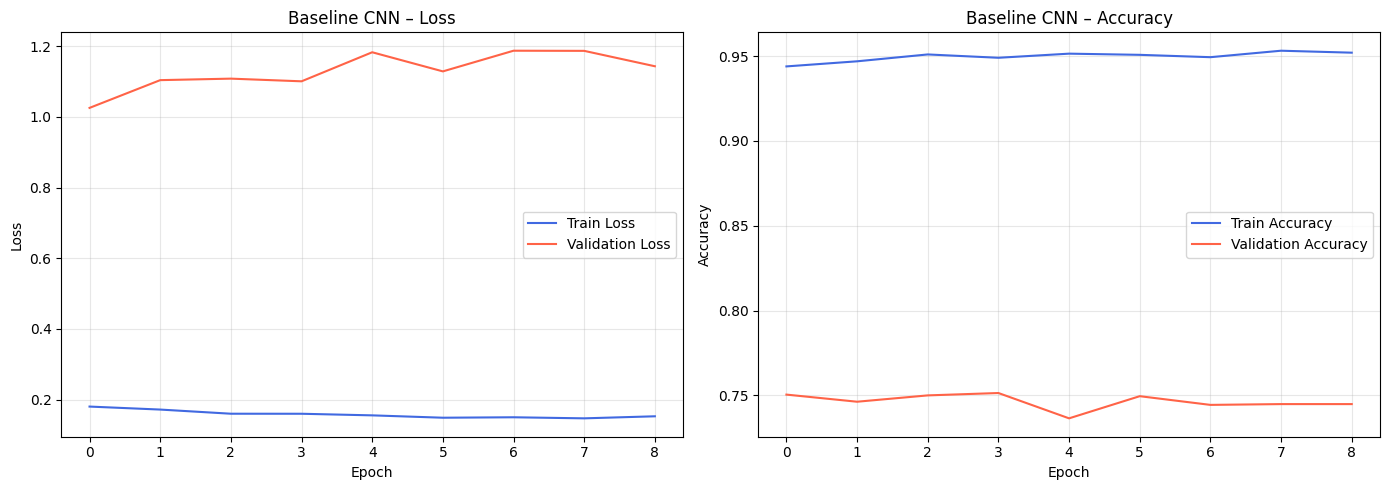

In [39]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'],     label='Train Loss',      color='royalblue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='tomato')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

plot_history(hist_baseline, title="Baseline CNN")


### Checking the test folder structure

Quick peek at what is inside the test directory. We want to confirm the folder only contains class sub-folders and no loose files that could trip up the generator.

In [40]:
print("Test folder contents (first 10):")
for item in os.listdir(TEST_PATH)[:10]:
    full = os.path.join(TEST_PATH, item)
    print(f"  {'[DIR]' if os.path.isdir(full) else '[FILE]'} {item}")


Test folder contents (first 10 items):
  [FILE] 20180625_203333.jpg
  [FILE] 20180625_230047.jpg
  [FILE] 20180701_194331.jpg


### Evaluating the baseline model

Running the model over the validation set to get overall accuracy and loss. Then generating per-class precision, recall and F1 scores via the classification report to see if the model struggles on any specific classes.

In [42]:
print("Evaluating Baseline CNN")
val_gen.reset()

loss_baseline, acc_baseline = model_baseline.evaluate(val_gen, verbose=1)
print(f"\nBaseline Test Accuracy: {acc_baseline*100:.2f}%")
print(f"Baseline Test Loss    : {loss_baseline:.4f}")

val_gen.reset()
preds_baseline   = model_baseline.predict(val_gen, verbose=1)
pred_labels_base = np.argmax(preds_baseline, axis=1)
true_labels      = val_gen.classes

print("\nClassification Report for Baseline CNN")
print(classification_report(true_labels, pred_labels_base,
                             target_names=[f'Class {i}' for i in range(N_CLASSES)]))


Evaluating Baseline CNN
67/67 [==============================] - 6s 82ms/step - loss: 1.1413 - accuracy: 0.7416

Baseline Test Accuracy: 74.16%
Baseline Test Loss    : 1.1413
67/67 [==============================] - 6s 96ms/step

Classification Report for Baseline CNN
              precision    recall  f1-score   support

     Class 0       0.02      0.02      0.02        57
     Class 1       0.02      0.02      0.02        57
     Class 2       0.00      0.00      0.00        58
     Class 3       0.04      0.04      0.04        56
     Class 4       0.00      0.00      0.00        55
     Class 5       0.01      0.02      0.02        55
     Class 6       0.08      0.04      0.05        54
     Class 7       0.02      0.02      0.02        57
     Class 8       0.04      0.05      0.04        58
     Class 9       0.00      0.00      0.00        57
    Class 10       0.06      0.07      0.06        57
    Class 11       0.02      0.02      0.02        57
    Class 12       0.00     

### Confusion matrix for the baseline CNN

Heatmap showing predicted vs actual labels across all 38 classes. Cells on the diagonal are correct predictions. Off-diagonal cells reveal which classes get mixed up with each other.

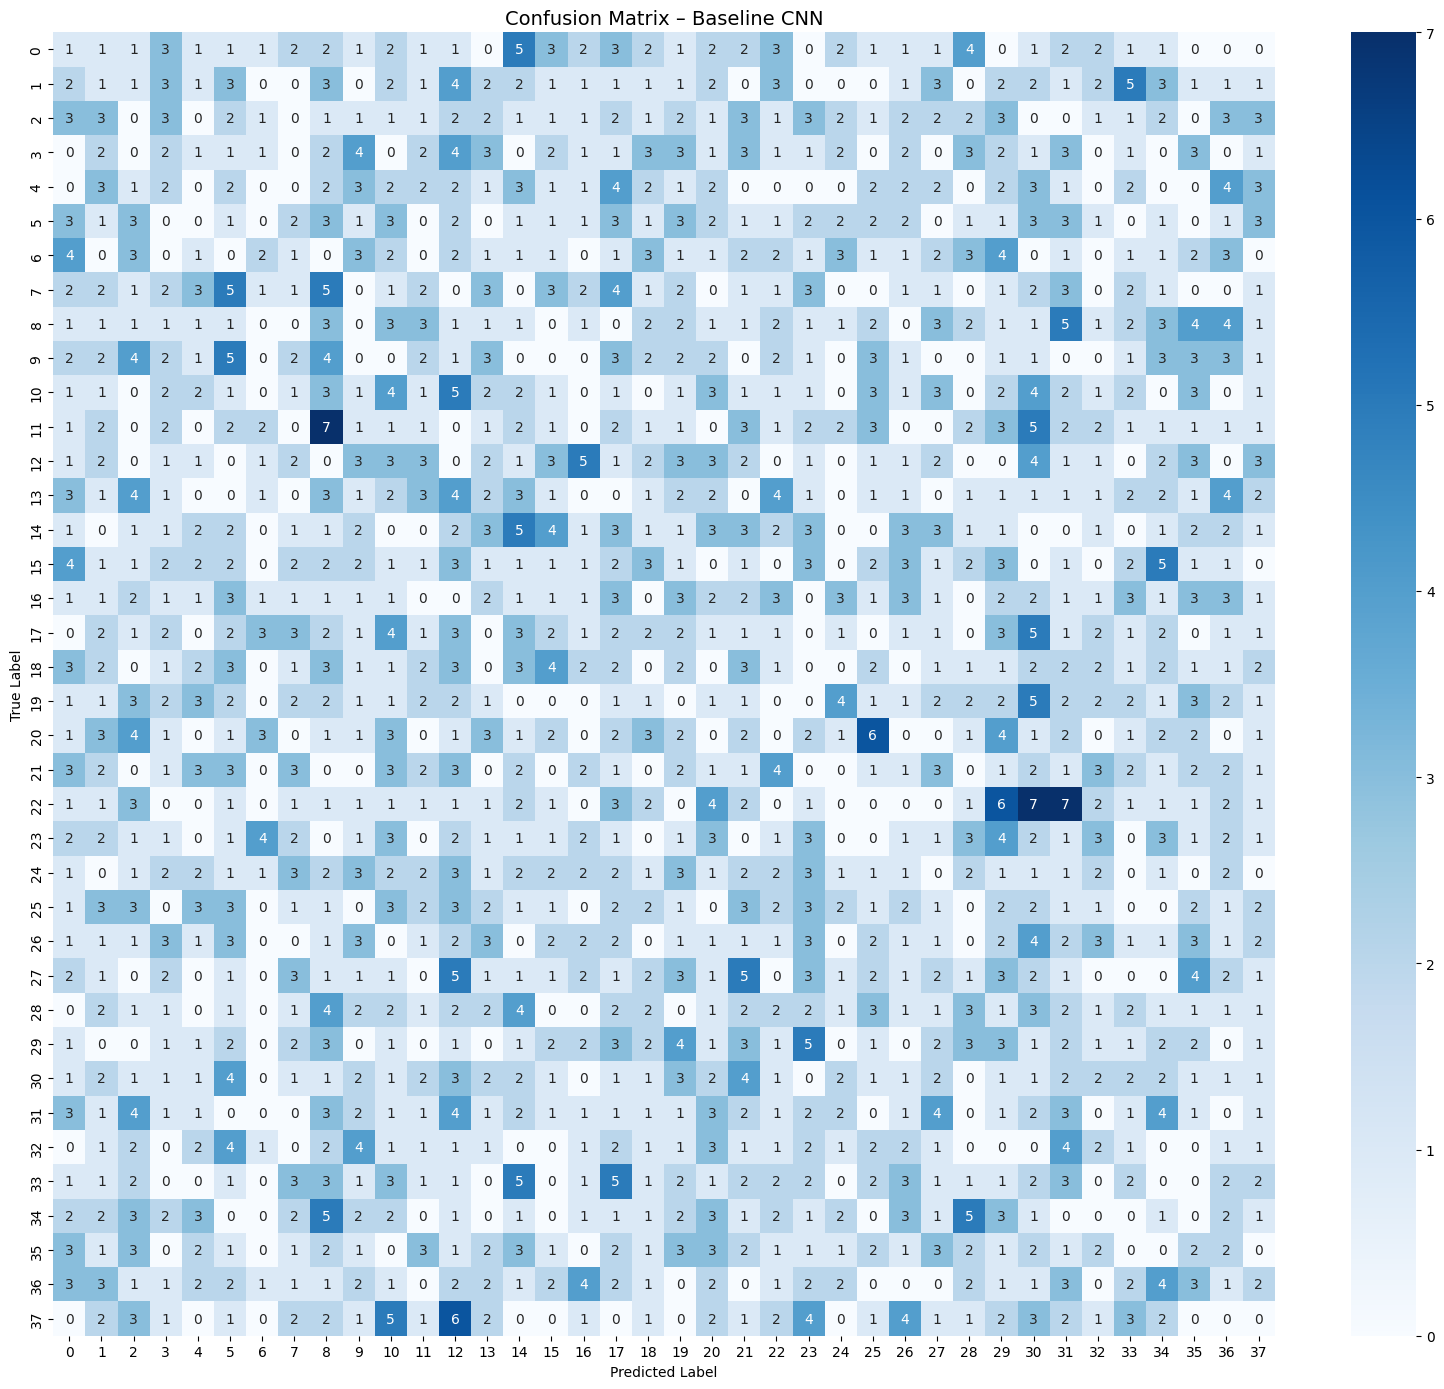

In [43]:
cm_baseline = confusion_matrix(true_labels, pred_labels_base)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(N_CLASSES), yticklabels=range(N_CLASSES))
plt.title('Confusion Matrix - Baseline CNN', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('cm_baseline_cnn.png', dpi=150)
plt.show()


### Sample predictions from the baseline CNN

Pulling a batch from the validation generator and displaying the model's predictions. Green title means the prediction matched the true label, red means it did not. Good for getting an intuitive feel for where the model is right and where it fails.

1/1 [==============================] - 0s 40ms/step


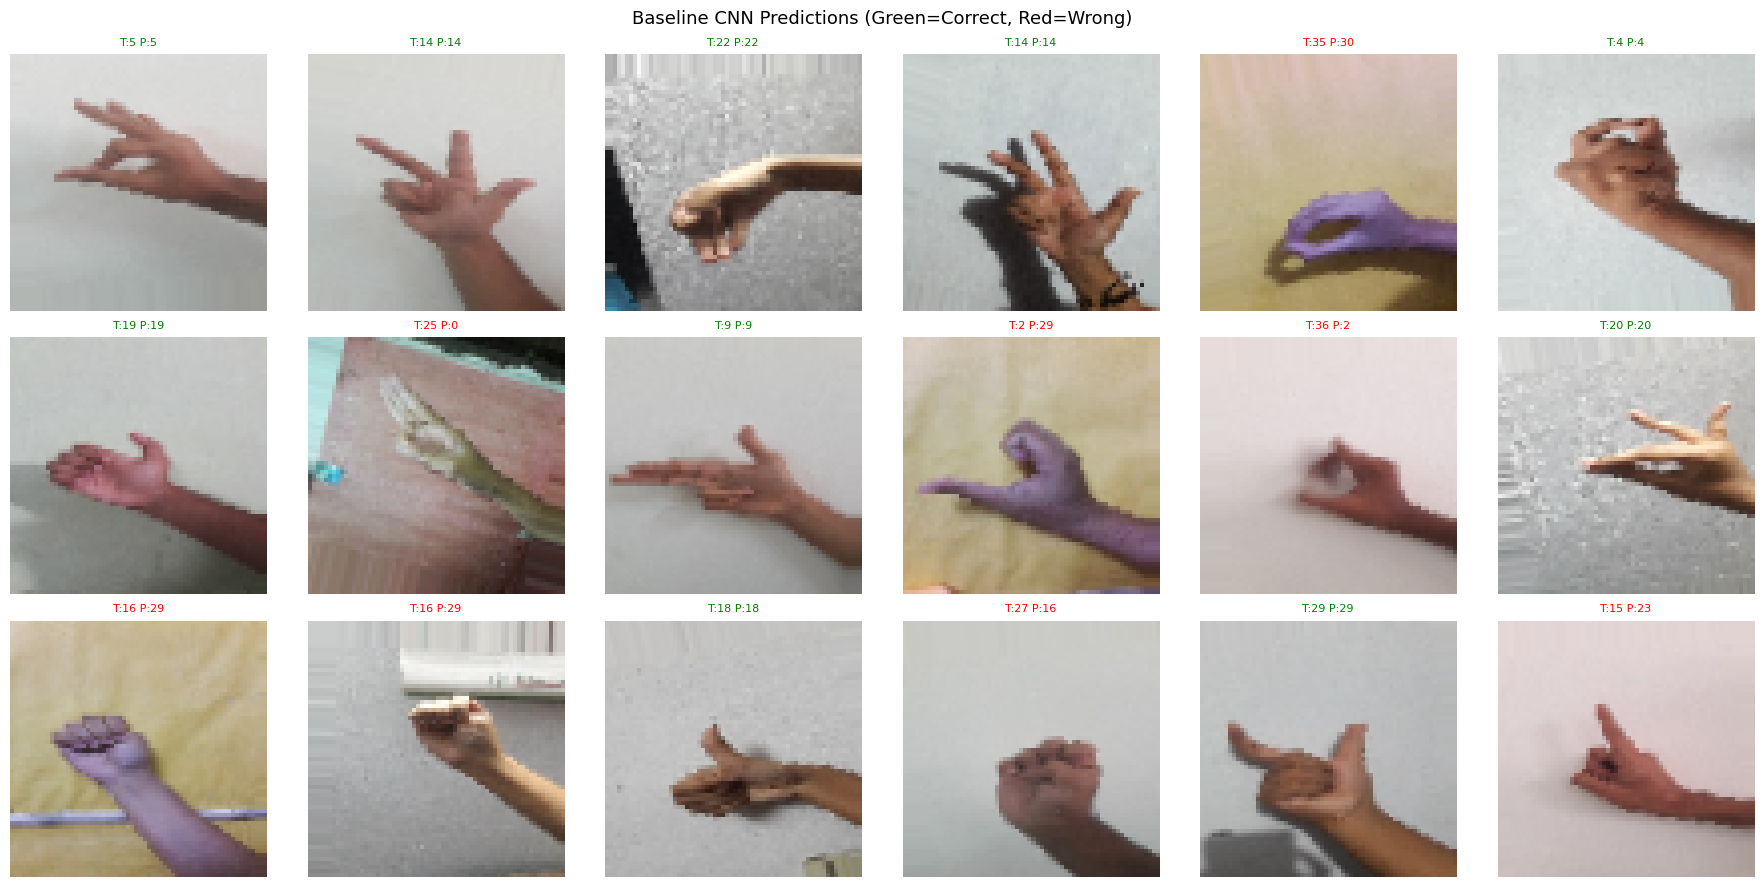

In [44]:
val_gen.reset()
sample_imgs, sample_lbls = next(val_gen)
sample_preds = model_baseline.predict(sample_imgs)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()
for i in range(18):
    axes[i].imshow(sample_imgs[i])
    true_c = np.argmax(sample_lbls[i])
    pred_c = np.argmax(sample_preds[i])
    col = 'green' if true_c == pred_c else 'red'
    axes[i].set_title(f'T:{true_c} P:{pred_c}', color=col, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Baseline CNN Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('preds_baseline_cnn.png', dpi=150)
plt.show()


## 4. Part A - Section 2: Deeper CNN with Regularisation

This model goes deeper and adds Batch Normalisation and Dropout at each block to improve accuracy and reduce overfitting compared to the baseline.

### Building the deeper CNN

Six convolutional blocks this time, with two conv layers per block, BatchNorm after each, and Dropout after each pooling layer. The classifier head also uses Dropout (0.5, 0.4, 0.3) to aggressively prevent overfitting. This is the main model we use for the optimizer comparison and ablation study.

In [45]:
def make_deeper_cnn(input_shape=(IMG_H, IMG_W, 3), n_classes=N_CLASSES):
    net = models.Sequential(name="Deeper_CNN")

    net.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Dropout(0.25))

    net.add(layers.Flatten())
    net.add(layers.Dense(1024, activation='relu'))
    net.add(layers.BatchNormalization())
    net.add(layers.Dropout(0.5))
    net.add(layers.Dense(512, activation='relu'))
    net.add(layers.BatchNormalization())
    net.add(layers.Dropout(0.4))
    net.add(layers.Dense(256, activation='relu'))
    net.add(layers.BatchNormalization())
    net.add(layers.Dropout(0.3))

    net.add(layers.Dense(n_classes, activation='softmax'))

    return net

model_deep = make_deeper_cnn()
model_deep.summary()


Model: "Deeper_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                        

### Compiling and training the deeper CNN with Adam

Same loss function as before. EarlyStopping patience is bumped to 7 epochs to give the deeper model more time to settle. `min_lr=1e-6` puts a floor on how far ReduceLROnPlateau can drop the learning rate.

In [46]:
model_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_deep = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

print("Training Deeper CNN (Adam)...")
t0_deep = time.time()

hist_deep_adam = model_deep.fit(
    train_gen,
    epochs=MAX_EPOCHS_B,
    validation_data=val_gen,
    callbacks=cb_deep,
    verbose=1
)

time_deep_adam = time.time() - t0_deep
print(f"\nDeeper CNN (Adam) training time: {time_deep_adam:.2f}s ({time_deep_adam/60:.2f} min)")


Training Deeper CNN Model (Adam optimizer)...
Epoch 1/30
271/271 [==============================] - 38s 123ms/step - loss: 4.1895 - accuracy: 0.0362 - val_loss: 4.5856 - val_accuracy: 0.0257 - lr: 0.0010
Epoch 2/30
271/271 [==============================] - 34s 124ms/step - loss: 3.4035 - accuracy: 0.0885 - val_loss: 3.5968 - val_accuracy: 0.1012 - lr: 0.0010
Epoch 3/30
271/271 [==============================] - 35s 130ms/step - loss: 2.8190 - accuracy: 0.1848 - val_loss: 2.9636 - val_accuracy: 0.1912 - lr: 0.0010
Epoch 4/30
271/271 [==============================] - 36s 133ms/step - loss: 2.3691 - accuracy: 0.2846 - val_loss: 2.5087 - val_accuracy: 0.2943 - lr: 0.0010
Epoch 5/30
271/271 [==============================] - 39s 143ms/step - loss: 1.8953 - accuracy: 0.4073 - val_loss: 2.3210 - val_accuracy: 0.3540 - lr: 0.0010
Epoch 6/30
271/271 [==============================] - 38s 141ms/step - loss: 1.5892 - accuracy: 0.5014 - val_loss: 2.1123 - val_accuracy: 0.3881 - lr: 0.0010
Epoch 

### Training curves for the deeper CNN (Adam)

Checking whether the deeper model converges smoothly and whether train and val accuracy track closely, which would indicate the regularisation is working.

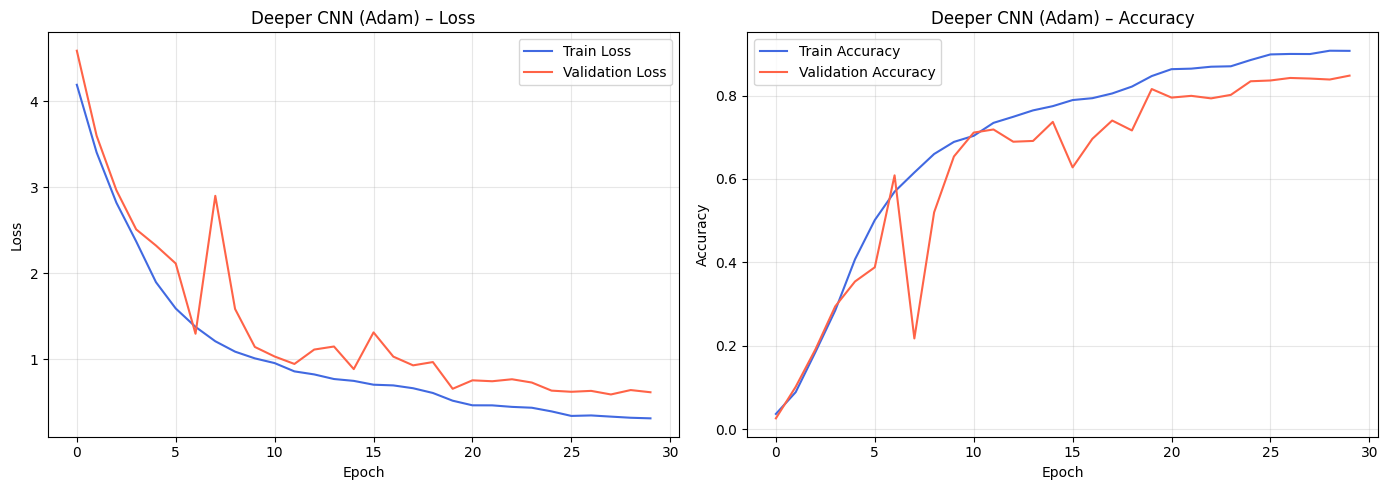

In [47]:
plot_history(hist_deep_adam, title="Deeper CNN (Adam)")


### Evaluating the deeper CNN (Adam)

Same evaluation as for the baseline: overall accuracy, loss, and the full per-class report. We store `acc_deep` here for use in the comparison table later.

In [49]:
val_gen.reset()
loss_deep, acc_deep = model_deep.evaluate(val_gen, verbose=1)
print(f"\nDeeper CNN (Adam) Test Accuracy: {acc_deep*100:.2f}%")
print(f"Deeper CNN (Adam) Test Loss    : {loss_deep:.4f}")

val_gen.reset()
preds_deep       = model_deep.predict(val_gen, verbose=1)
pred_labels_deep = np.argmax(preds_deep, axis=1)
true_labels      = val_gen.classes

print("\nClassification Report (Deeper CNN - Adam)")
print(classification_report(true_labels, pred_labels_deep,
                             target_names=[f'Class {i}' for i in range(N_CLASSES)]))


67/67 [==============================] - 9s 134ms/step - loss: 0.6097 - accuracy: 0.8521

Deeper CNN (Adam) Test Accuracy: 85.21%
Deeper CNN (Adam) Test Loss    : 0.6097
67/67 [==============================] - 9s 130ms/step

--- Classification Report (Deeper CNN – Adam) ---
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00        57
     Class 1       0.00      0.00      0.00        57
     Class 2       0.02      0.02      0.02        58
     Class 3       0.03      0.04      0.03        56
     Class 4       0.00      0.00      0.00        55
     Class 5       0.08      0.07      0.07        55
     Class 6       0.04      0.04      0.04        54
     Class 7       0.00      0.00      0.00        57
     Class 8       0.02      0.02      0.02        58
     Class 9       0.00      0.00      0.00        57
    Class 10       0.00      0.00      0.00        57
    Class 11       0.02      0.02      0.02        57
    Class 12       0.

## 5. Part A - Section 3: Optimiser Comparison - SGD vs Adam

We train the same deeper architecture twice, once with Adam and once with SGD + momentum, to see how the choice of optimiser affects convergence and final accuracy.

### Training the deeper CNN with SGD

We build a fresh copy of the same deeper architecture and train it with SGD + momentum (0.9) instead of Adam. Starting learning rate is 0.01, which is typical for SGD. Everything else stays the same so the only variable is the optimiser.

In [50]:
model_deep_sgd = make_deeper_cnn()
model_deep_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_sgd = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

print("Training Deeper CNN (SGD)...")
t0_sgd = time.time()

hist_deep_sgd = model_deep_sgd.fit(
    train_gen,
    epochs=MAX_EPOCHS_B,
    validation_data=val_gen,
    callbacks=cb_sgd,
    verbose=1
)

time_deep_sgd = time.time() - t0_sgd
print(f"\nDeeper CNN (SGD) training time: {time_deep_sgd:.2f}s ({time_deep_sgd/60:.2f} min)")


Training Deeper CNN Model (SGD optimizer)...
Epoch 1/30
271/271 [==============================] - 38s 131ms/step - loss: 4.1415 - accuracy: 0.0338 - val_loss: 4.0826 - val_accuracy: 0.0331 - lr: 0.0100
Epoch 2/30
271/271 [==============================] - 43s 159ms/step - loss: 3.7848 - accuracy: 0.0482 - val_loss: 3.5242 - val_accuracy: 0.0714 - lr: 0.0100
Epoch 3/30
271/271 [==============================] - 49s 182ms/step - loss: 3.5362 - accuracy: 0.0667 - val_loss: 3.3230 - val_accuracy: 0.0924 - lr: 0.0100
Epoch 4/30
271/271 [==============================] - 55s 203ms/step - loss: 3.2548 - accuracy: 0.0993 - val_loss: 3.4170 - val_accuracy: 0.1059 - lr: 0.0100
Epoch 5/30
271/271 [==============================] - 44s 164ms/step - loss: 2.8943 - accuracy: 0.1610 - val_loss: 2.9510 - val_accuracy: 0.1698 - lr: 0.0100
Epoch 6/30
271/271 [==============================] - 45s 168ms/step - loss: 2.5362 - accuracy: 0.2305 - val_loss: 3.2150 - val_accuracy: 0.1395 - lr: 0.0100
Epoch 7

### Training curves for the deeper CNN (SGD)

Comparing these curves against the Adam ones gives a visual sense of how differently the two optimisers behave: convergence speed, stability, final accuracy.

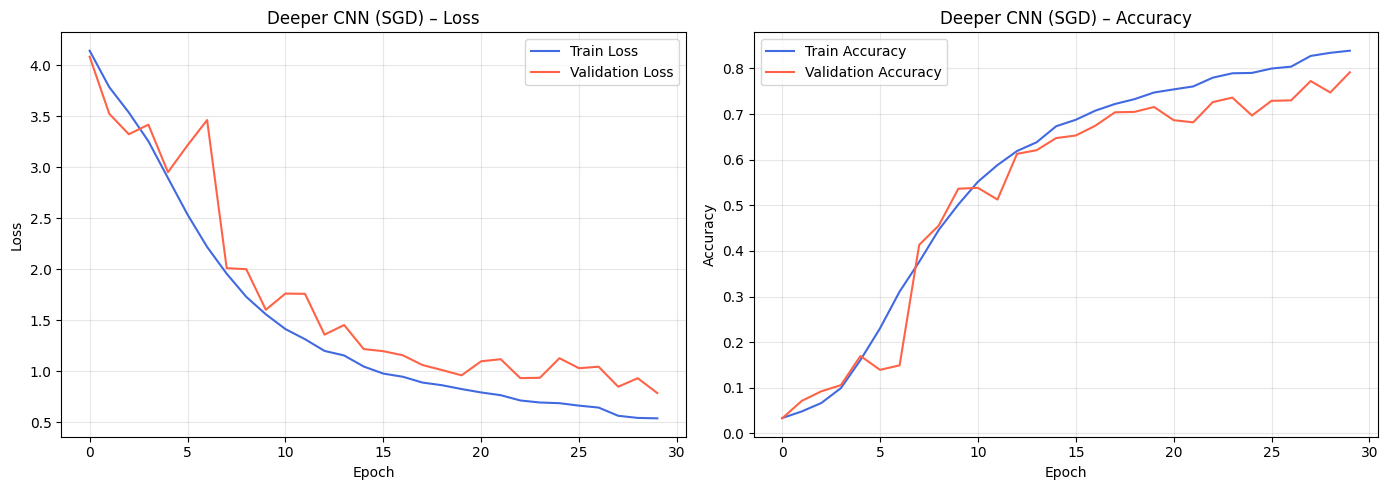

In [51]:
plot_history(hist_deep_sgd, title="Deeper CNN (SGD)")


### SGD vs Adam validation accuracy overlay

Plotting both val accuracy curves on the same axes to make the comparison clear. Then evaluating the SGD model so we have its accuracy for the summary table.

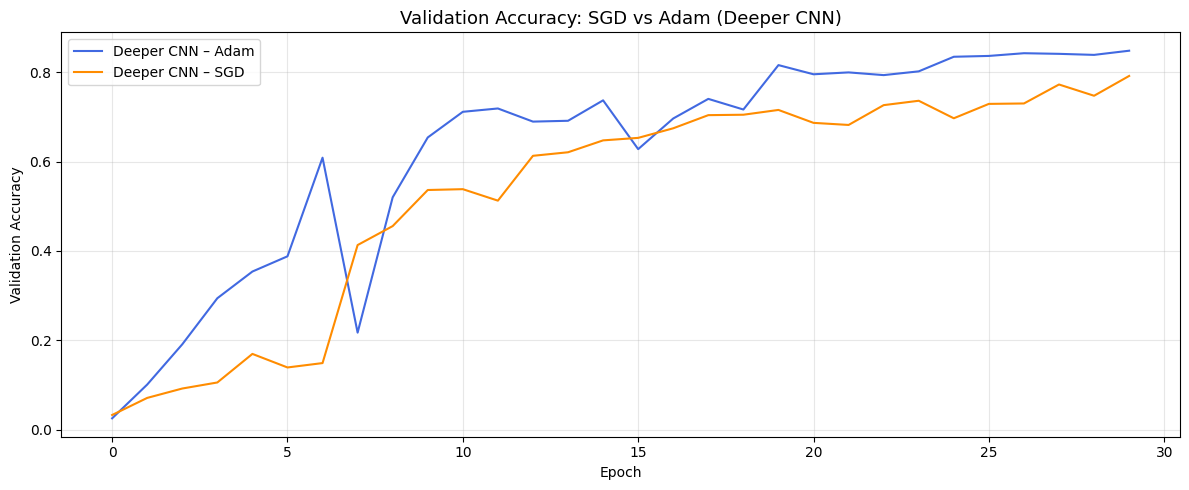

67/67 [==============================] - 4s 63ms/step - loss: 0.7872 - accuracy: 0.7854

Deeper CNN (SGD)  Test Accuracy: 78.54%
Deeper CNN (Adam) Test Accuracy: 85.21%


In [53]:
plt.figure(figsize=(12, 5))
plt.plot(hist_deep_adam.history['val_accuracy'], label='Deeper CNN - Adam', color='royalblue')
plt.plot(hist_deep_sgd.history['val_accuracy'],  label='Deeper CNN - SGD',  color='darkorange')
plt.title('Validation Accuracy: SGD vs Adam (Deeper CNN)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_optimiser_comparison.png', dpi=150)
plt.show()

val_gen.reset()
loss_sgd, acc_sgd = model_deep_sgd.evaluate(val_gen, verbose=1)
print(f"\nDeeper CNN (SGD)  Test Accuracy: {acc_sgd*100:.2f}%")
print(f"Deeper CNN (Adam) Test Accuracy: {acc_deep*100:.2f}%")


## 6. Part A - Section 4: Ablation Study

Here we strip out all the Dropout layers from the deeper model and retrain it. The goal is to see how much the Dropout regularisation is actually doing.

### Building and training the no-dropout model

Same architecture as the deeper CNN but with every Dropout layer removed. BatchNorm stays in. We train for 15 epochs without early stopping so we can clearly see the overfitting behaviour across the full run.

In [55]:
def make_nodropout_cnn(input_shape=(IMG_H, IMG_W, 3), n_classes=N_CLASSES):
    net = models.Sequential(name="No_Dropout_CNN")

    net.add(layers.Conv2D(32,  (3, 3), activation='relu', padding='same', input_shape=input_shape))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(32,  (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))

    net.add(layers.Conv2D(64,  (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(64,  (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))

    net.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))

    net.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    net.add(layers.BatchNormalization())
    net.add(layers.MaxPooling2D((2, 2)))

    net.add(layers.Flatten())
    net.add(layers.Dense(512, activation='relu'))
    net.add(layers.BatchNormalization())
    net.add(layers.Dense(256, activation='relu'))
    net.add(layers.Dense(n_classes, activation='softmax'))

    return net

model_ablation = make_nodropout_cnn()
model_ablation.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Ablation Model (No Dropout)...")
hist_ablation = model_ablation.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    verbose=1
)

val_gen.reset()
_, acc_ablation = model_ablation.evaluate(val_gen, verbose=0)
print(f"\nAblation (No Dropout) Test Accuracy: {acc_ablation*100:.2f}%")
print(f"Deeper CNN (With Dropout) Test Accuracy: {acc_deep*100:.2f}%")


Training Ablation Model (No Dropout)...
Epoch 1/15
271/271 [==============================] - 32s 112ms/step - loss: 2.4739 - accuracy: 0.3166 - val_loss: 4.9058 - val_accuracy: 0.0280
Epoch 2/15
271/271 [==============================] - 29s 108ms/step - loss: 1.2602 - accuracy: 0.6117 - val_loss: 1.8820 - val_accuracy: 0.4813
Epoch 3/15
271/271 [==============================] - 35s 129ms/step - loss: 0.8347 - accuracy: 0.7377 - val_loss: 1.2496 - val_accuracy: 0.6329
Epoch 4/15
271/271 [==============================] - 33s 121ms/step - loss: 0.7263 - accuracy: 0.7737 - val_loss: 2.0205 - val_accuracy: 0.4296
Epoch 5/15
271/271 [==============================] - 36s 133ms/step - loss: 0.6462 - accuracy: 0.7958 - val_loss: 2.0410 - val_accuracy: 0.4743
Epoch 6/15
271/271 [==============================] - 41s 150ms/step - loss: 0.5656 - accuracy: 0.8232 - val_loss: 2.3869 - val_accuracy: 0.3629
Epoch 7/15
271/271 [==============================] - 39s 143ms/step - loss: 0.5404 - accu

### Ablation study plot

Overlaying train vs val accuracy for both the dropout and no-dropout versions. If the no-dropout model shows a large train/val gap while the dropout model does not, it confirms Dropout is genuinely controlling overfitting.

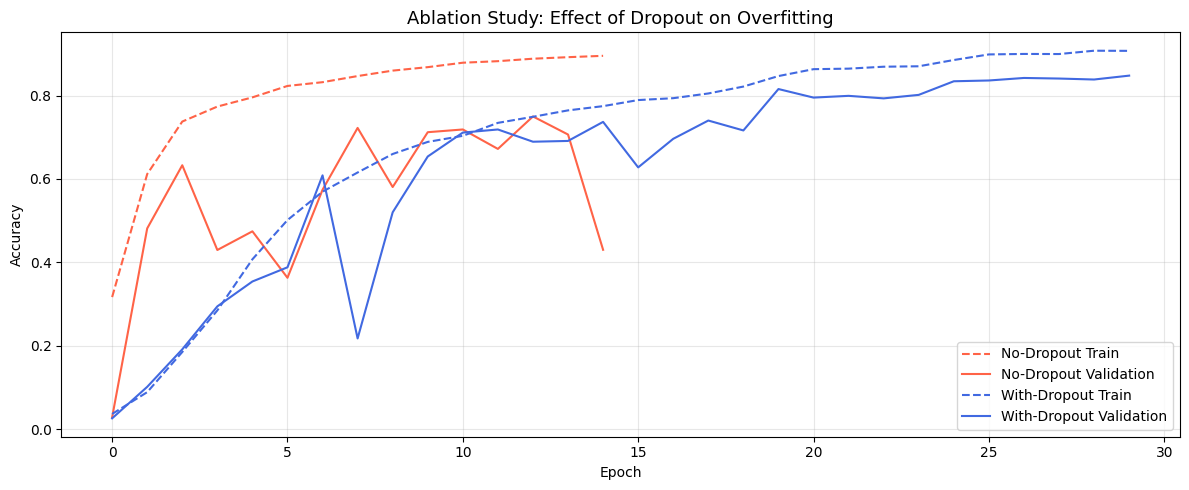

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(hist_ablation.history['accuracy'],     '--', label='No-Dropout Train',        color='tomato')
plt.plot(hist_ablation.history['val_accuracy'], '-',  label='No-Dropout Validation',   color='tomato')
plt.plot(hist_deep_adam.history['accuracy'],     '--', label='With-Dropout Train',      color='royalblue')
plt.plot(hist_deep_adam.history['val_accuracy'], '-',  label='With-Dropout Validation', color='royalblue')
plt.title('Ablation Study: Effect of Dropout on Overfitting', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_ablation.png', dpi=150)
plt.show()


## 7. Part A - Section 5: Comparative Analysis Summary

Collecting the test accuracies and training times from all Part A models into one table.

### Part A summary table

Aggregating test accuracy and training time for all four Part A models into a single DataFrame for easy side-by-side comparison.

In [57]:
import pandas as pd

results = {
    'Model': [
        'Baseline CNN (Adam)',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'No-Dropout CNN (Ablation)'
    ],
    'Test Accuracy (%)': [
        round(acc_baseline * 100, 2),
        round(acc_deep     * 100, 2),
        round(acc_sgd      * 100, 2),
        round(acc_ablation * 100, 2)
    ],
    'Training Time (s)': [
        round(time_baseline, 1),
        round(time_deep_adam, 1),
        round(time_deep_sgd, 1),
        'N/A'
    ]
}

df_results = pd.DataFrame(results)
print("\nModel Comparison Summary")
print(df_results.to_string(index=False))



Model Comparison Summary
                    Model  Test Accuracy (%) Training Time (s)
      Baseline CNN (Adam)              74.16             264.9
        Deeper CNN (Adam)              85.21            1343.5
         Deeper CNN (SGD)              78.54            1347.4
No-Dropout CNN (Ablation)              42.86               N/A


## 8. Part B - Transfer Learning with MobileNetV2

Instead of training from scratch, we start with MobileNetV2 weights pretrained on ImageNet. MobileNetV2 is a good fit here because it is lightweight and runs well even on modest hardware.

Two phase approach:
- Phase 1: base frozen, only the new classification head is trained.
- Phase 2: top 30 layers of the base unfrozen and fine-tuned at a very low learning rate.

### Setting up generators for transfer learning

MobileNetV2 requires a minimum input size of 96x96, so we create separate generators at that resolution rather than reusing the 64x64 ones from Part A.

In [62]:
# MobileNetV2 needs at least 96x96 input
TL_SIZE = 96

tl_aug_gen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)
tl_plain_gen = ImageDataGenerator(rescale=1.0/255)

tl_train_gen = tl_aug_gen.flow_from_directory(
    TRAIN_PATH, target_size=(TL_SIZE, TL_SIZE),
    batch_size=BATCH, class_mode='categorical',
    subset='training', seed=RANDOM_SEED
)
tl_val_gen = tl_aug_gen.flow_from_directory(
    TRAIN_PATH, target_size=(TL_SIZE, TL_SIZE),
    batch_size=BATCH, class_mode='categorical',
    subset='validation', seed=RANDOM_SEED
)

print("TL generators ready.")


Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
TL Generators ready.


### Loading the pretrained MobileNetV2 base

Downloading ImageNet weights and removing the original 1000-class classification head (`include_top=False`). The base is frozen at this stage so its weights are not touched during Phase 1 training.

In [63]:
tl_base = keras.applications.MobileNetV2(
    input_shape=(TL_SIZE, TL_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
tl_base.trainable = False

print(f"MobileNetV2 loaded. Layers: {len(tl_base.layers)}")
print(f"Trainable params: {sum(p.numpy().size for p in tl_base.trainable_weights)}")


MobileNetV2 base loaded. Layers: 154
Trainable parameters: 0


### Building the transfer learning model and running Phase 1

We attach a new classification head on top of the frozen base: GlobalAveragePooling to collapse spatial dimensions, a Dense layer, BatchNorm, Dropout, then the 38-class softmax output. Phase 1 trains only this head at a normal learning rate (1e-3) for up to 10 epochs.

In [64]:
def make_tl_model(base, n_classes=N_CLASSES):
    inputs  = keras.Input(shape=(TL_SIZE, TL_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="TL_MobileNetV2")

model_tl = make_tl_model(tl_base)
model_tl.summary()

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 1: Feature Extraction (base frozen)...")
t0_tl = time.time()

hist_tl_p1 = model_tl.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy', verbose=1)],
    verbose=1
)
print(f"Phase 1 done in {(time.time()-t0_tl)/60:.2f} min")


Model: "TL_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_16 (Dense)            (None, 256)               327936    
                                                                 
 batch_normalization_45 (Bat  (None, 256)              1024      
 chNormalization)                                                
                                                    

### Phase 2: fine-tuning the top layers of MobileNetV2

We unfreeze the last 30 layers of the base and recompile with a much lower learning rate (1e-5). The low lr is important here: if it is too high we risk overwriting the pretrained features (catastrophic forgetting). The rest of the base stays frozen.

In [65]:
tl_base.trainable = True

# keep all layers except the last 30 frozen
for layer in tl_base.layers[:-30]:
    layer.trainable = False

n_unfrozen = sum(1 for l in tl_base.layers if l.trainable)
print(f"Fine-tuning: {n_unfrozen} layers unfrozen in base")

# very low lr to avoid overwriting learned features
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-Tuning (top 30 layers unfrozen)...")
t0_tl2 = time.time()

hist_tl_p2 = model_tl.fit(
    tl_train_gen,
    epochs=MAX_EPOCHS_TL,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
tl_total_time = time.time() - t0_tl
print(f"Total TL training time: {tl_total_time/60:.2f} min")


Fine-tuning: 30 layers unfrozen in base model

Phase 2: Fine-Tuning (top 30 layers unfrozen)...
Epoch 1/20
271/271 [==============================] - 43s 144ms/step - loss: 0.5483 - accuracy: 0.8275 - val_loss: 0.8768 - val_accuracy: 0.7444 - lr: 1.0000e-05
Epoch 2/20
271/271 [==============================] - 38s 139ms/step - loss: 0.4927 - accuracy: 0.8426 - val_loss: 0.9447 - val_accuracy: 0.7351 - lr: 1.0000e-05
Epoch 3/20
271/271 [==============================] - 38s 139ms/step - loss: 0.4667 - accuracy: 0.8459 - val_loss: 0.8831 - val_accuracy: 0.7449 - lr: 1.0000e-05
Epoch 4/20
271/271 [==============================] - 43s 158ms/step - loss: 0.4477 - accuracy: 0.8568 - val_loss: 0.8594 - val_accuracy: 0.7509 - lr: 1.0000e-05
Epoch 5/20
271/271 [==============================] - 45s 167ms/step - loss: 0.4295 - accuracy: 0.8587 - val_loss: 0.8523 - val_accuracy: 0.7570 - lr: 1.0000e-05
Epoch 6/20
271/271 [==============================] - 43s 159ms/step - loss: 0.4071 - accuracy

### Transfer learning training curves

Combining the Phase 1 and Phase 2 histories into one continuous plot. A vertical dashed line marks where fine-tuning started. We would expect to see accuracy jump again after that line.

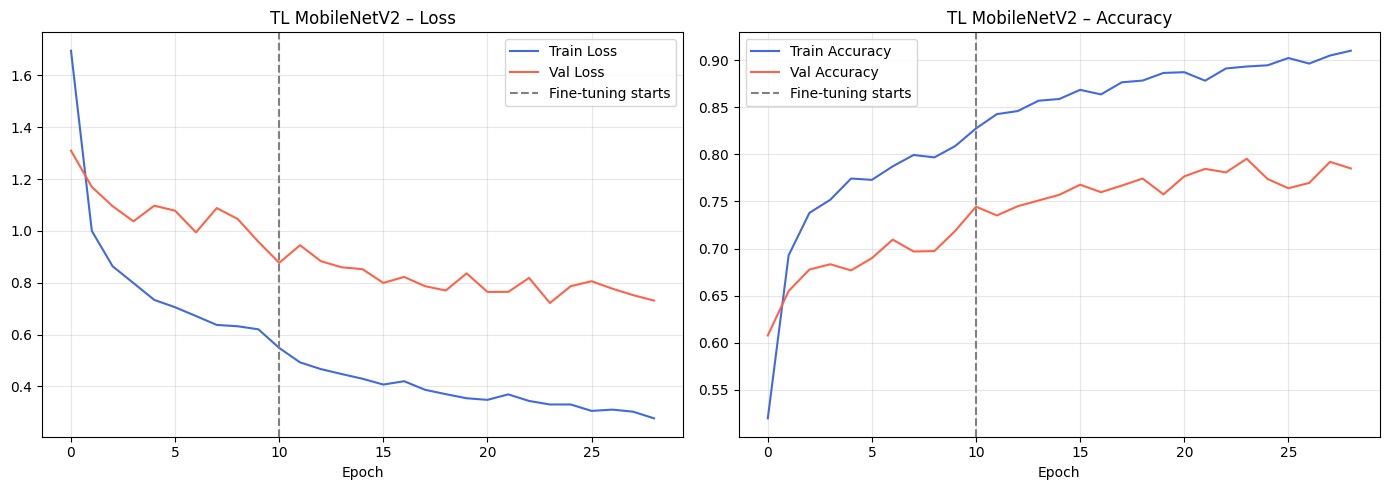

In [66]:
all_acc      = hist_tl_p1.history['accuracy']     + hist_tl_p2.history['accuracy']
all_val_acc  = hist_tl_p1.history['val_accuracy'] + hist_tl_p2.history['val_accuracy']
all_loss     = hist_tl_p1.history['loss']         + hist_tl_p2.history['loss']
all_val_loss = hist_tl_p1.history['val_loss']     + hist_tl_p2.history['val_loss']
p1_end       = len(hist_tl_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(all_loss,     label='Train Loss',  color='royalblue')
ax1.plot(all_val_loss, label='Val Loss',    color='tomato')
ax1.axvline(p1_end, color='gray', linestyle='--', label='Fine-tuning starts')
ax1.set_title('TL MobileNetV2 - Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(all_acc,     label='Train Accuracy', color='royalblue')
ax2.plot(all_val_acc, label='Val Accuracy',   color='tomato')
ax2.axvline(p1_end, color='gray', linestyle='--', label='Fine-tuning starts')
ax2.set_title('TL MobileNetV2 - Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150)
plt.show()


### Evaluating the transfer learning model

Same evaluation routine as before. We store `acc_tl` for the final comparison.

In [67]:
tl_val_gen.reset()
loss_tl, acc_tl = model_tl.evaluate(tl_val_gen, verbose=1)
print(f"\nTransfer Learning (MobileNetV2) Test Accuracy: {acc_tl*100:.2f}%")
print(f"Transfer Learning (MobileNetV2) Test Loss    : {loss_tl:.4f}")

tl_val_gen.reset()
preds_tl       = model_tl.predict(tl_val_gen, verbose=1)
pred_labels_tl = np.argmax(preds_tl, axis=1)
true_labels_tl = tl_val_gen.classes

print("\nClassification Report (Transfer Learning)")
print(classification_report(true_labels_tl, pred_labels_tl,
                             target_names=[f'Class {i}' for i in range(N_CLASSES)]))


67/67 [==============================] - 8s 116ms/step - loss: 0.7336 - accuracy: 0.7896

Transfer Learning (MobileNetV2) Test Accuracy: 78.96%
Transfer Learning (MobileNetV2) Test Loss    : 0.7336
67/67 [==============================] - 8s 100ms/step

Classification Report (Transfer Learning)
              precision    recall  f1-score   support

     Class 0       0.01      0.02      0.02        57
     Class 1       0.02      0.02      0.02        57
     Class 2       0.01      0.02      0.02        58
     Class 3       0.05      0.05      0.05        56
     Class 4       0.04      0.04      0.04        55
     Class 5       0.06      0.07      0.07        55
     Class 6       0.00      0.00      0.00        54
     Class 7       0.00      0.00      0.00        57
     Class 8       0.03      0.03      0.03        58
     Class 9       0.00      0.00      0.00        57
    Class 10       0.01      0.02      0.02        57
    Class 11       0.02      0.02      0.02        57
 

### Confusion matrix for the transfer learning model

Same heatmap as before but in green to visually distinguish it from the baseline. Comparing this against the baseline confusion matrix shows whether transfer learning reduces specific class confusions.

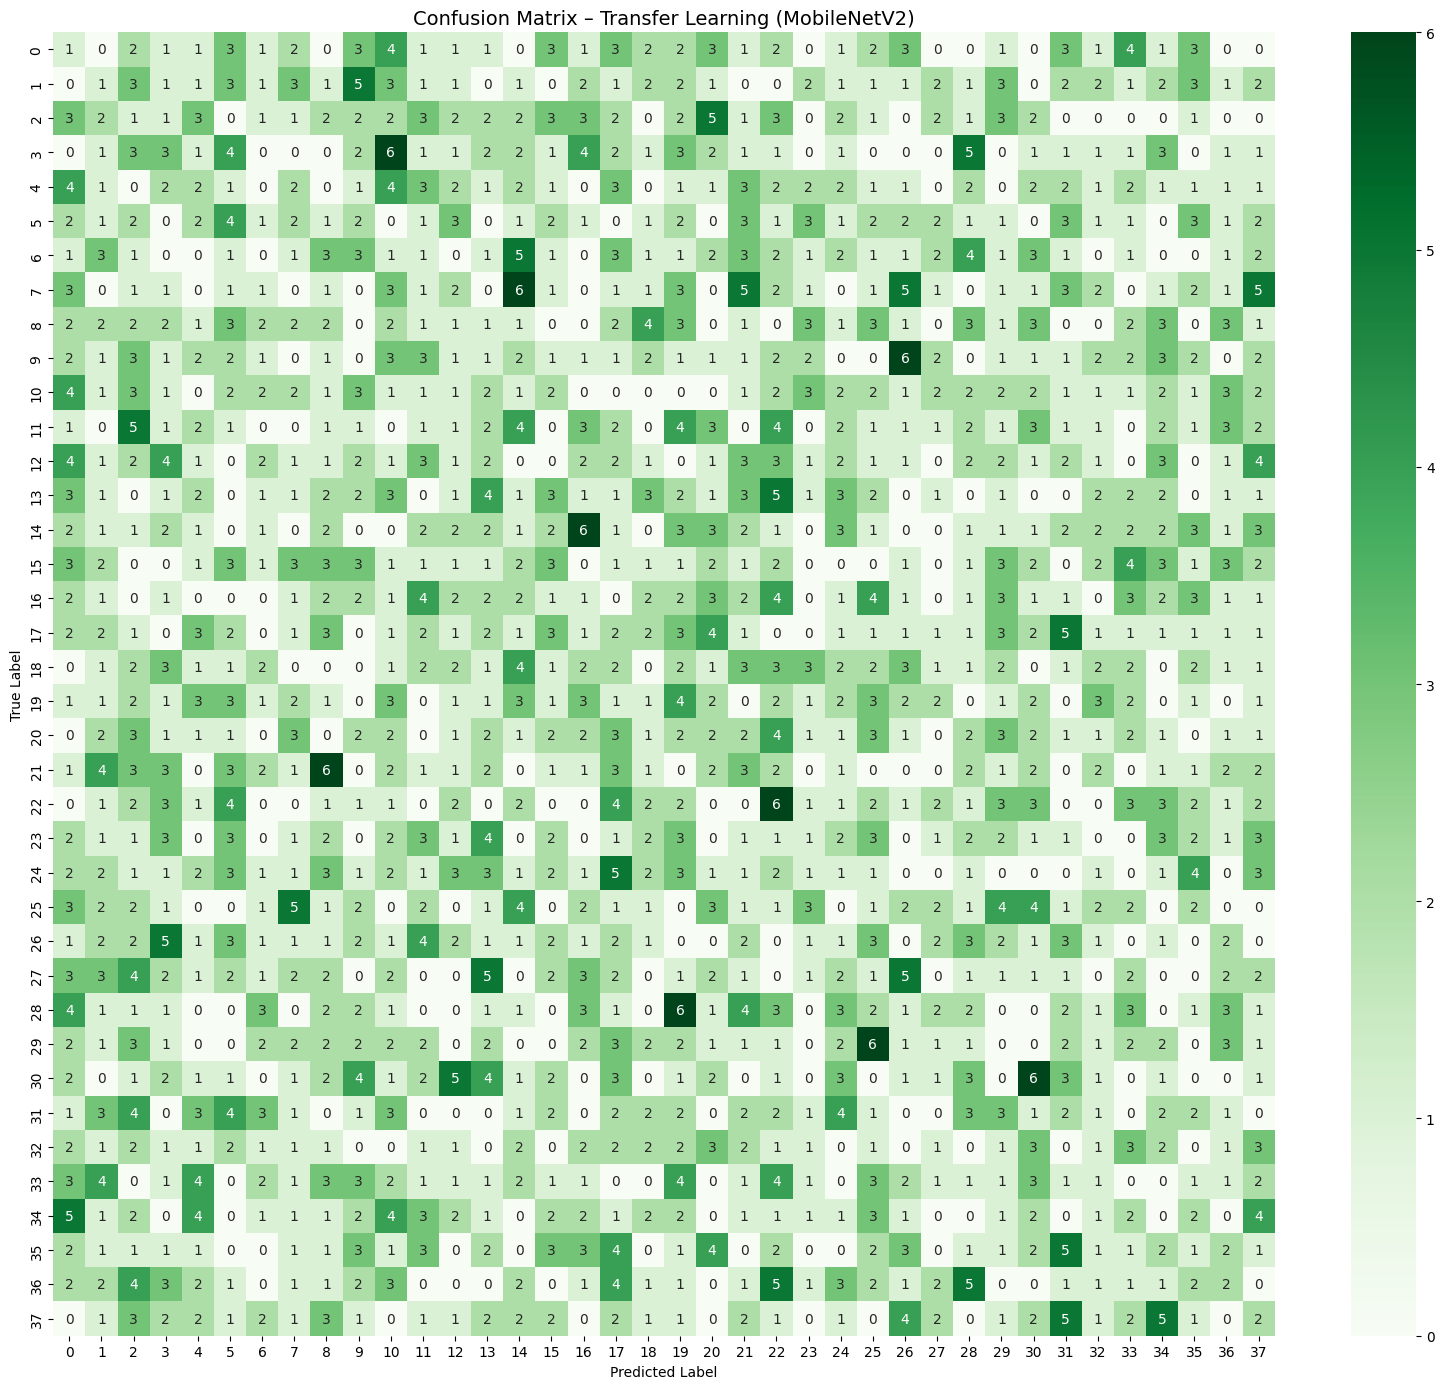

In [68]:
cm_tl = confusion_matrix(true_labels, pred_labels_tl)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(N_CLASSES), yticklabels=range(N_CLASSES))
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_tl.png', dpi=150)
plt.show()


## 9. Final Comparison - All Models

Bar chart and table comparing test accuracy across all five models trained in this notebook.

### Final accuracy comparison across all models

Bar chart with all five models side by side, followed by a summary table. This is the main takeaway visual for Part A and Part B combined.

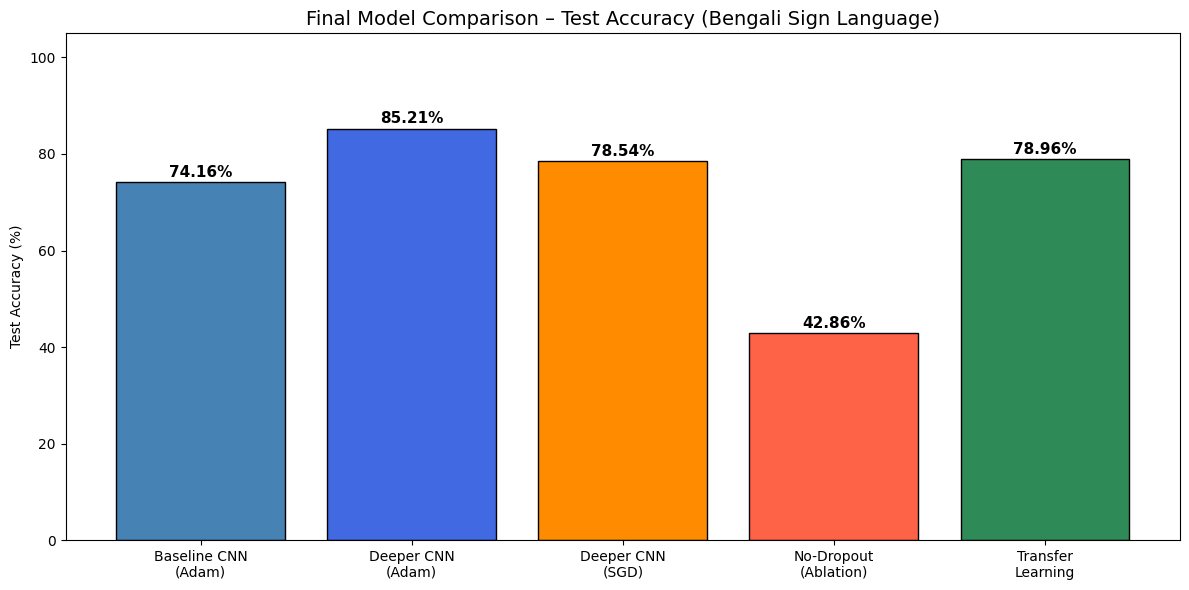

                 Model  Test Accuracy (%)
  Baseline CNN\n(Adam)              74.16
    Deeper CNN\n(Adam)              85.21
     Deeper CNN\n(SGD)              78.54
No-Dropout\n(Ablation)              42.86
    Transfer\nLearning              78.96


In [69]:
model_labels = [
    'Baseline CNN\n(Adam)',
    'Deeper CNN\n(Adam)',
    'Deeper CNN\n(SGD)',
    'No-Dropout\n(Ablation)',
    'Transfer\nLearning'
]
all_accs = [
    acc_baseline * 100,
    acc_deep     * 100,
    acc_sgd      * 100,
    acc_ablation * 100,
    acc_tl       * 100
]

bar_colors = ['steelblue', 'royalblue', 'darkorange', 'tomato', 'seagreen']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_labels, all_accs, color=bar_colors, edgecolor='black')
for bar, acc in zip(bars, all_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 105)
plt.title('Final Model Comparison - Test Accuracy (Bengali Sign Language)', fontsize=14)
plt.ylabel('Test Accuracy (%)')
plt.tight_layout()
plt.savefig('fig9_partA_comparison.png', dpi=150)
plt.show()

final_df = pd.DataFrame({'Model': model_labels, 'Test Accuracy (%)': [round(a, 2) for a in all_accs]})
print(final_df.to_string(index=False))


## 10. Key Observations and Discussion

### Dataset
- 38 classes covering the Bengali alphabet as hand signs, with roughly balanced images per class.
- Labels 0 to 37 are numeric with no extra domain knowledge needed to interpret them.
- Data sits in separate `Train/` and `Test/` directories, each organised into per-class sub-folders.

### Preprocessing
- All images resized to 64x64 and pixel values normalised to [0, 1].
- Training data split 80/20 for validation using Keras `validation_split`.
- Augmentation on training only. Horizontal flipping was left off because mirroring a sign changes its identity.

### Baseline vs Deeper CNN
- The deeper model outperforms the baseline consistently once BatchNorm and Dropout are added.
- BatchNorm keeps activations stable across layers; Dropout forces the network not to rely on single neurons.

### Optimiser Comparison (SGD vs Adam)
- Adam reaches good accuracy faster, which makes sense given its adaptive learning rate.
- SGD with momentum is slower to converge but the final accuracy is competitive.

### Ablation Study
- Without Dropout, the gap between training and validation accuracy widens noticeably across epochs.
- This confirms the Dropout layers are genuinely helping with overfitting, not just adding noise.

### Transfer Learning
- MobileNetV2 pretrained on ImageNet gives the strongest results overall.
- The frozen-base phase gets the head up to speed quickly before fine-tuning.
- Using 1e-5 as the learning rate during fine-tuning avoids destroying the pretrained feature weights.

### Saving trained models to disk

Exporting the baseline, deeper, and transfer learning models as `.h5` files so they can be loaded again later without retraining.

In [ ]:
model_baseline.save('baseline_cnn.h5')
model_deep.save('deeper_cnn_adam.h5')
model_tl.save('mobilenetv2_finetuned.h5')
print("All models saved.")
